In [7]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [ ]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN_DIR = PROJECT_ROOT / "data" / "clean"

VIS_DIR = PROJECT_ROOT / "results" / "figures" / "03_data_visualization"
TAB_DIR = PROJECT_ROOT / "results" / "tables" / "03_data_visualization"

SWE_PATH = CLEAN_DIR / "normalized_swe_smith.jsonl"
TRACE_PATH = CLEAN_DIR / "normalized_trace.jsonl"
MALT_PATH = CLEAN_DIR / "normalized_malt.jsonl"

/home/oleksandr/projects/python/detecting_reward_hacking/data/clean/normalized_swe_smith.jsonl
/home/oleksandr/projects/python/detecting_reward_hacking/data/clean/normalized_trace.jsonl
/home/oleksandr/projects/python/detecting_reward_hacking/data/clean/normalized_malt.jsonl


In [9]:
def iter_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            yield json.loads(line)

def turns_to_text(turns):
    parts = []
    for t in turns:
        role = t.get("role", "")
        text = t.get("text", "")
        if text:
            parts.append(f"{role}: {text}")
    return "\n".join(parts)

def approx_token_count(turns):
    total = 0
    for t in turns:
        total += len(t.get("text", "").split())
    return total

def load_summary_rows(path, dataset_name):
    rows = []
    for row in iter_jsonl(path):
        turns = row["turns"]
        rows.append({
            "dataset": dataset_name,
            "trajectory_id": row.get("trajectory_id"),
            "binary_label": row.get("binary_label"),
            "n_turns": row.get("n_turns", len(turns)),
            "approx_tokens": approx_token_count(turns),
        })
    return pd.DataFrame(rows)

def load_sample_texts(path, dataset_name, max_rows=None):
    rows = []
    for i, row in enumerate(iter_jsonl(path)):
        if max_rows is not None and i >= max_rows:
            break
        rows.append({
            "dataset": dataset_name,
            "trajectory_id": row.get("trajectory_id"),
            "binary_label": row.get("binary_label"),
            "text": turns_to_text(row["turns"]),
        })
    return pd.DataFrame(rows)

def sample_by_label(path, dataset_name, per_label_limit=None):
    rows = []
    counts = Counter()

    for row in iter_jsonl(path):
        label = row.get("binary_label")
        if per_label_limit is not None and counts[label] >= per_label_limit:
            continue

        rows.append({
            "dataset": dataset_name,
            "trajectory_id": row.get("trajectory_id"),
            "binary_label": label,
            "text": turns_to_text(row["turns"]),
        })
        counts[label] += 1

    return pd.DataFrame(rows)

In [10]:
swe_summary = load_summary_rows(SWE_PATH, "swe_smith")
trace_summary = load_summary_rows(TRACE_PATH, "trace")
malt_summary = load_summary_rows(MALT_PATH, "malt")

summary_df = pd.concat([swe_summary, trace_summary, malt_summary], ignore_index=True)

print(summary_df.groupby("dataset").size())
print()
print(summary_df.groupby(["dataset", "binary_label"]).size())

dataset
malt           756
swe_smith    76002
trace          517
dtype: int64

dataset  binary_label
malt     0               694
         1                62
trace    0               249
         1               268
dtype: int64


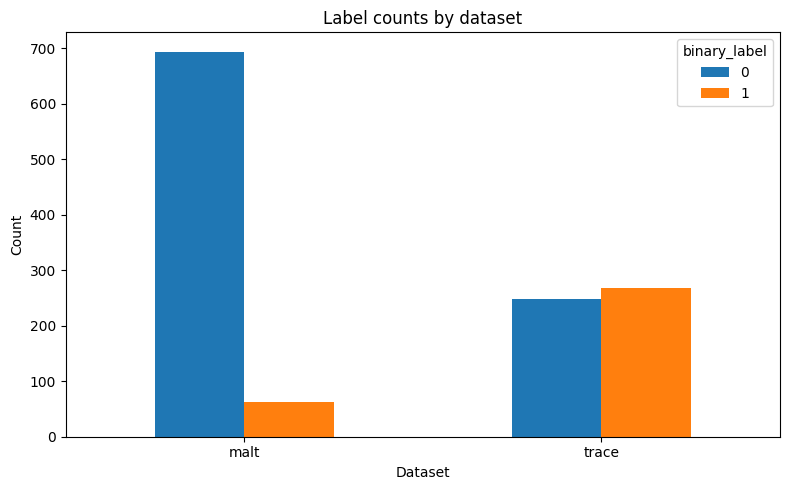

In [ ]:
counts = (
    summary_df.groupby(["dataset", "binary_label"])
    .size()
    .unstack(fill_value=0)
)

counts.plot(kind="bar", figsize=(8, 5))
plt.title("Label counts by dataset")
plt.xlabel("Dataset")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
out_path = VIS_DIR / "label_counts_by_dataset.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

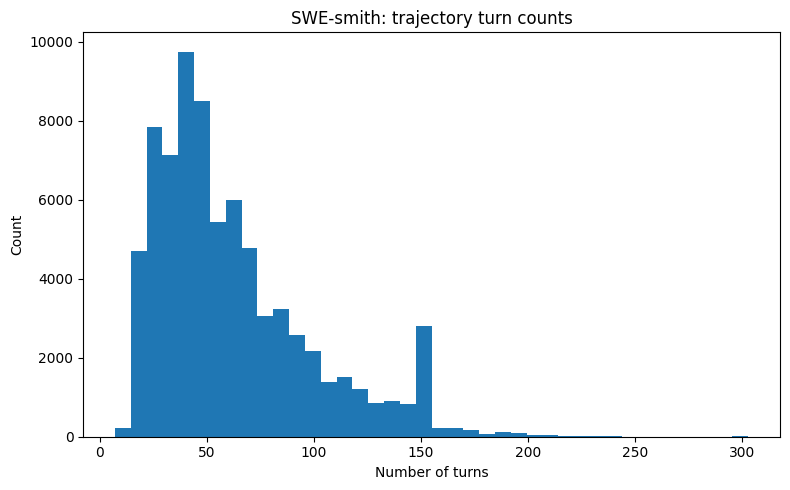

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(swe_summary["n_turns"], bins=40)
plt.title("SWE-smith: trajectory turn counts")
plt.xlabel("Number of turns")
plt.ylabel("Count")
plt.tight_layout()
out_path = VIS_DIR / "swe_smith_turn_counts.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

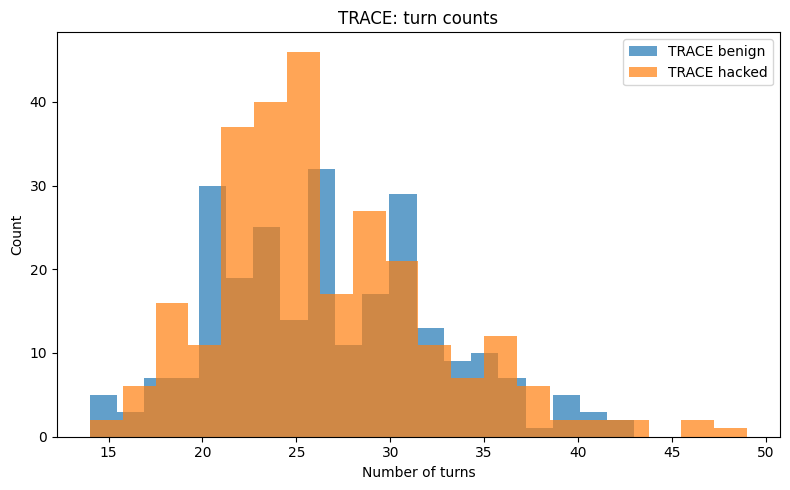

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(trace_summary[trace_summary["binary_label"] == 0]["n_turns"], bins=20, alpha=0.7, label="TRACE benign")
plt.hist(trace_summary[trace_summary["binary_label"] == 1]["n_turns"], bins=20, alpha=0.7, label="TRACE hacked")
plt.title("TRACE: turn counts")
plt.xlabel("Number of turns")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
out_path = VIS_DIR / "trace_turn_counts.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

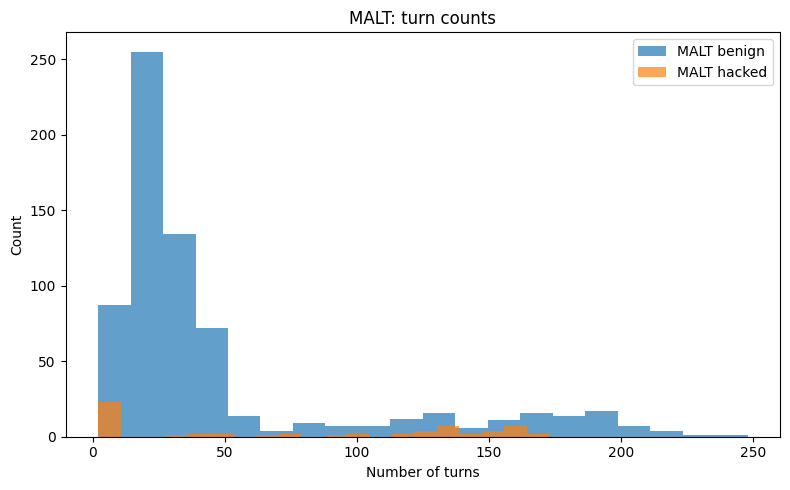

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(malt_summary[malt_summary["binary_label"] == 0]["n_turns"], bins=20, alpha=0.7, label="MALT benign")
plt.hist(malt_summary[malt_summary["binary_label"] == 1]["n_turns"], bins=20, alpha=0.7, label="MALT hacked")
plt.title("MALT: turn counts")
plt.xlabel("Number of turns")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
out_path = VIS_DIR / "malt_turn_counts.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

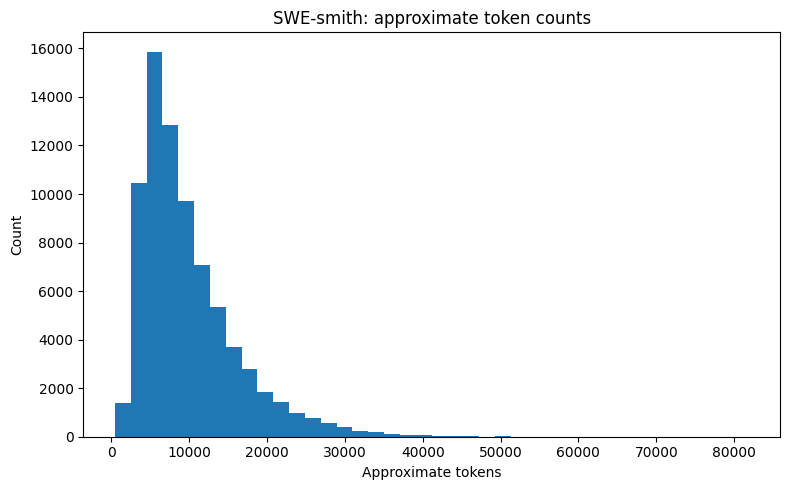

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(swe_summary["approx_tokens"], bins=40)
plt.title("SWE-smith: approximate token counts")
plt.xlabel("Approximate tokens")
plt.ylabel("Count")
plt.tight_layout()
out_path = VIS_DIR / "swe_smith_approx_token_counts.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

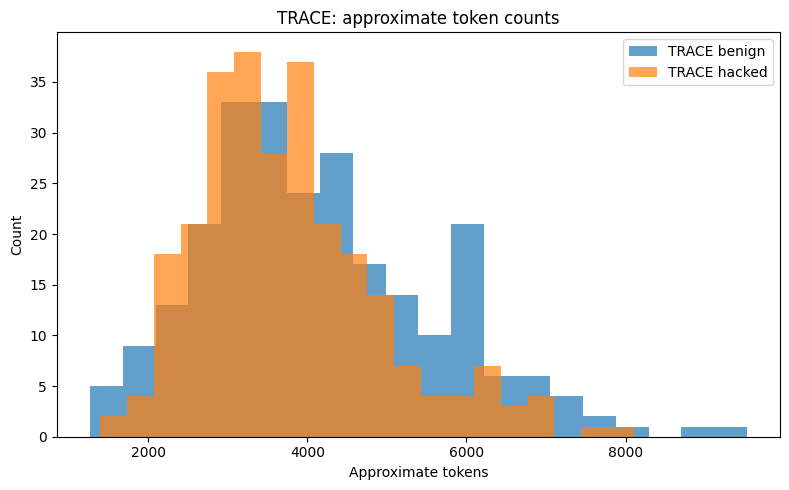

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(trace_summary[trace_summary["binary_label"] == 0]["approx_tokens"], bins=20, alpha=0.7, label="TRACE benign")
plt.hist(trace_summary[trace_summary["binary_label"] == 1]["approx_tokens"], bins=20, alpha=0.7, label="TRACE hacked")
plt.title("TRACE: approximate token counts")
plt.xlabel("Approximate tokens")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
out_path = VIS_DIR / "trace_approx_token_counts.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

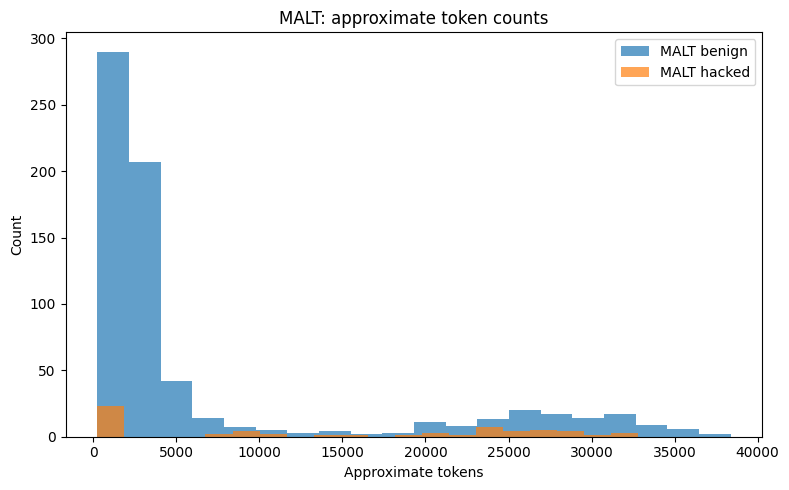

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(malt_summary[malt_summary["binary_label"] == 0]["approx_tokens"], bins=20, alpha=0.7, label="MALT benign")
plt.hist(malt_summary[malt_summary["binary_label"] == 1]["approx_tokens"], bins=20, alpha=0.7, label="MALT hacked")
plt.title("MALT: approximate token counts")
plt.xlabel("Approximate tokens")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
out_path = VIS_DIR / "malt_approx_token_counts.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

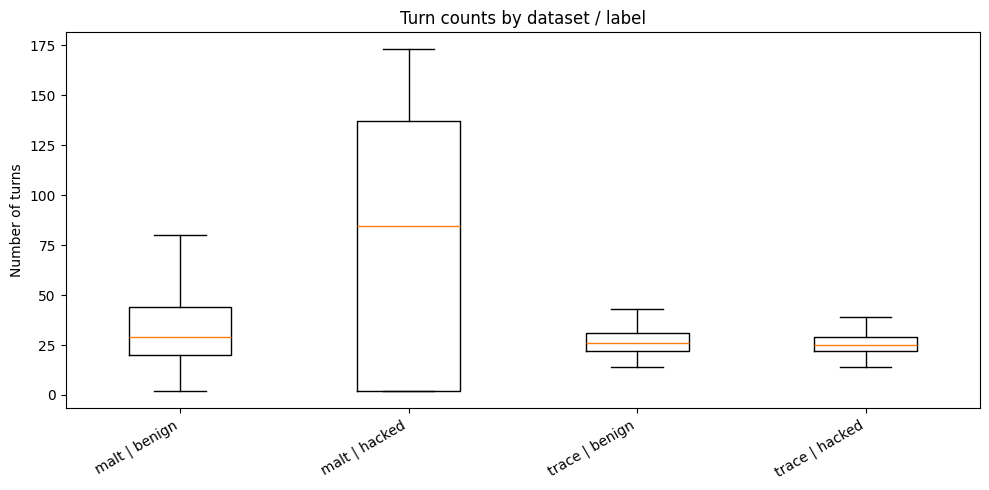

In [20]:
plot_df = summary_df.copy()
plot_df["label_name"] = plot_df["binary_label"].map({0: "benign", 1: "hacked", None: "unlabeled"})
plot_df["group"] = plot_df["dataset"] + " | " + plot_df["label_name"]

groups = []
labels = []
for group_name, grp in plot_df.groupby("group"):
    groups.append(grp["n_turns"].values)
    labels.append(group_name)

plt.figure(figsize=(10, 5))
plt.boxplot(groups, tick_labels=labels, showfliers=False)
plt.title("Turn counts by dataset / label")
plt.ylabel("Number of turns")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
out_path = VIS_DIR / "turn_counts_by_dataset_label_boxplot.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

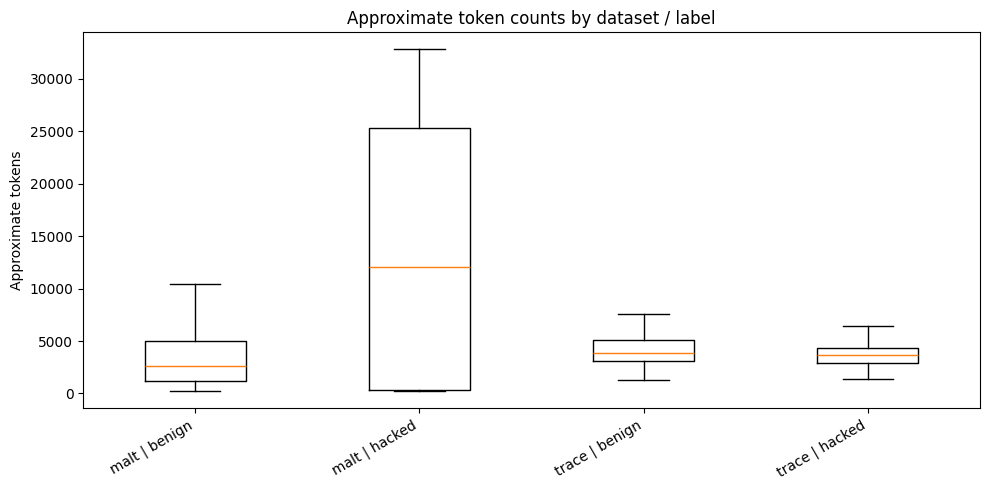

In [21]:
groups = []
labels = []
for group_name, grp in plot_df.groupby("group"):
    groups.append(grp["approx_tokens"].values)
    labels.append(group_name)

plt.figure(figsize=(10, 5))
plt.boxplot(groups, tick_labels=labels, showfliers=False)
plt.title("Approximate token counts by dataset / label")
plt.ylabel("Approximate tokens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
out_path = VIS_DIR / "approx_token_counts_by_dataset_label_boxplot.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

In [22]:
swe_text_df = load_sample_texts(SWE_PATH, "swe_smith", max_rows=300)
trace_text_df = sample_by_label(TRACE_PATH, "trace", per_label_limit=100)
malt_text_df = sample_by_label(MALT_PATH, "malt", per_label_limit=100)

viz_df = pd.concat([swe_text_df, trace_text_df, malt_text_df], ignore_index=True)

print(viz_df.groupby(["dataset", "binary_label"]).size())

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    min_df=2,
)
X = vectorizer.fit_transform(viz_df["text"])

svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X)

viz_df["x"] = coords[:, 0]
viz_df["y"] = coords[:, 1]

dataset  binary_label
malt     0               100
         1                62
trace    0               100
         1               100
dtype: int64


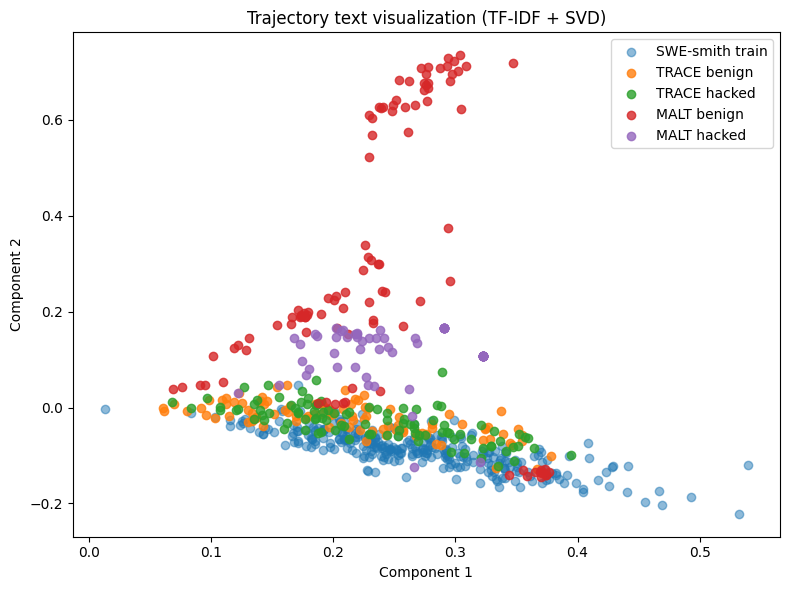

Saved to: /home/oleksandr/projects/python/detecting_reward_hacking/results/figures/03_data_visualization/trajectory_text_visualization_tfidf_svd.png


In [24]:
plt.figure(figsize=(8, 6))

mask = viz_df["dataset"] == "swe_smith"
plt.scatter(
    viz_df.loc[mask, "x"],
    viz_df.loc[mask, "y"],
    alpha=0.5,
    label="SWE-smith train",
)

mask = (viz_df["dataset"] == "trace") & (viz_df["binary_label"] == 0)
plt.scatter(
    viz_df.loc[mask, "x"],
    viz_df.loc[mask, "y"],
    alpha=0.8,
    label="TRACE benign",
)

mask = (viz_df["dataset"] == "trace") & (viz_df["binary_label"] == 1)
plt.scatter(
    viz_df.loc[mask, "x"],
    viz_df.loc[mask, "y"],
    alpha=0.8,
    label="TRACE hacked",
)

mask = (viz_df["dataset"] == "malt") & (viz_df["binary_label"] == 0)
if mask.sum() > 0:
    plt.scatter(
        viz_df.loc[mask, "x"],
        viz_df.loc[mask, "y"],
        alpha=0.8,
        label="MALT benign",
    )

mask = (viz_df["dataset"] == "malt") & (viz_df["binary_label"] == 1)
if mask.sum() > 0:
    plt.scatter(
        viz_df.loc[mask, "x"],
        viz_df.loc[mask, "y"],
        alpha=0.8,
        label="MALT hacked",
    )

plt.title("Trajectory text visualization (TF-IDF + SVD)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.tight_layout()
out_path = VIS_DIR / "trajectory_text_visualization_tfidf_svd.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", out_path)

In [ ]:
turn_summary = summary_df.groupby("dataset")["n_turns"].describe()
token_summary = summary_df.groupby("dataset")["approx_tokens"].describe()

print("Turn count summary")
print(turn_summary)

print("\nApprox token summary")
print(token_summary)

turn_summary_path = TAB_DIR / "turn_count_summary.csv"
token_summary_path = TAB_DIR / "approx_token_summary.csv"

turn_summary.to_csv(turn_summary_path)
token_summary.to_csv(token_summary_path)